<a href="https://colab.research.google.com/github/findmhel/OpenLens/blob/main/opf_spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proposta da EDA: identificar o perfil dos grupos que aderem e não aderem ao open finance e realizar uma análise comportamental destes grupos.


O dataset foi divido em 3 partes:


*   Perfil demográfico do cliente;
*   Comportamento financeiro;
* Comportamento digital.



In [ ]:
!pip install pyspark #Instalando o pyspark
!apt-get install openjdk-11-jdk -y #Instalando o Java na versão 11

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk-headless openjdk-11-jre openjdk-11-jre-headless
  session-migration x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm libnss-mdns
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk openjdk-11-jdk-headless openjdk-

In [ ]:
#Importando bibliotecas pyspark e criando a SparkSession
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import when, col, trim, upper, regexp_replace, to_date, months_between, current_date, sum as _sum
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler #ML/features
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.classification import RandomForestClassificationModel

#Iniciando Spark
spark = SparkSession.builder.appName("OpenFinanceAnalysis").getOrCreate()

#Importando bibliotecas pandas, matplotlib e seaborn para plotagem de gráficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

In [ ]:
 #Lendo o arquivo csv
data_spark = spark.read.csv('dados_opf (1).csv', header=True, inferSchema=True)

#Ver nomes originais
data_spark.printSchema()

root
 |-- cliente: string (nullable = true)
 |-- data_nascimento: string (nullable = true)
 |-- idade: integer (nullable = true)
 |-- estado_residencia: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- ocupacao: string (nullable = true)
 |-- grau_escolaridade: string (nullable = true)
 |-- estado_civil: string (nullable = true)
 |-- possui_filhos: integer (nullable = true)
 |-- saldo_conta: double (nullable = true)
 |-- renda: double (nullable = true)
 |-- score_credito: double (nullable = true)
 |-- possui_outros_bancos: integer (nullable = true)
 |-- possui_emprestimo: integer (nullable = true)
 |-- possui_financiamento: integer (nullable = true)
 |-- possui_cartao_credito: integer (nullable = true)
 |-- limite_cartao: double (nullable = true)
 |-- gastos_mensais: double (nullable = true)
 |-- usa_pix: integer (nullable = true)
 |-- usa_internet_banking: integer (nullable = true)
 |-- usa_app_banco: integer (nullable = true)
 |-- usa_cheque: integer (nullable = true)

In [ ]:
#Renomeando as colunas
rename_map = {
    'cliente' : 'Cliente',
    'data_nascimento': 'Nascimento',
    'idade' : 'Idade',
    'estado_residencia' : 'Estado',
    'sexo' : 'Sexo',
    'ocupacao' : 'Ocupacao',
    'grau_escolaridade' : 'Escolaridade',
    'estado_civil' : 'Estado_civil',
    'possui_filhos' : 'Qt_de_filhos',
    'saldo_conta' :'Saldo_em_conta',
    'renda' : 'Renda',
    'tipo_conta' : 'Tipo_da_conta',
    'score_credito' : 'Score_de_credito',
    'limite_cartao' : 'Limite_do_cartao',
    'gastos_mensais' : 'Gasto_mensal',
    'possui_outros_bancos' :'Outros_bancos',
    'possui_emprestimo' : 'Emprestimo',
    'possui_financiamento' : 'Financiamento',
    'possui_cartao_credito' : 'Cartao_de_credito',
    'usa_pix' : 'Usa_pix',
    'usa_internet_banking' : 'Usa_eBanking',
    'usa_app_banco' : 'Usa_app_banco',
    'usa_cheque' : 'Usa_cheque',
    'atraso_pagamentos' : 'Atrasa_pag',
    'tempo_conta_ativa' : 'Tempo_conta_atv',
    'investimentos' : 'Investimentos',
    'adesao-ao-open-finance' : 'Adesao_ao_OPF'
}

for old_name, new_name in rename_map.items():
    data_spark = data_spark.withColumnRenamed(old_name, new_name)

data_spark.printSchema()

root
 |-- Cliente: string (nullable = true)
 |-- Nascimento: string (nullable = true)
 |-- Idade: integer (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Sexo: string (nullable = true)
 |-- Ocupacao: string (nullable = true)
 |-- Escolaridade: string (nullable = true)
 |-- Estado_civil: string (nullable = true)
 |-- Qt_de_filhos: integer (nullable = true)
 |-- Saldo_em_conta: double (nullable = true)
 |-- Renda: double (nullable = true)
 |-- Score_de_credito: double (nullable = true)
 |-- Outros_bancos: integer (nullable = true)
 |-- Emprestimo: integer (nullable = true)
 |-- Financiamento: integer (nullable = true)
 |-- Cartao_de_credito: integer (nullable = true)
 |-- Limite_do_cartao: double (nullable = true)
 |-- Gasto_mensal: double (nullable = true)
 |-- Usa_pix: integer (nullable = true)
 |-- Usa_eBanking: integer (nullable = true)
 |-- Usa_app_banco: integer (nullable = true)
 |-- Usa_cheque: integer (nullable = true)
 |-- Atrasa_pag: integer (nullable = true)
 |--

In [ ]:
#Dropando as colunas irrelevantes ou pouco relevantes para a análise
cols_to_drop = ['cliente', 'aderiu_novo_servico']
for col in cols_to_drop:
    if col in data_spark.columns:
        data_spark = data_spark.drop(col)

In [ ]:
data_spark.summary().show()

+-------+--------------------+----------+------------------+--------------+-----+-------------+------------+------------+------------------+------------------+-----------------+------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+--------------------+--------------+------------------+------------------+------------------+
|summary|             Cliente|Nascimento|             Idade|        Estado| Sexo|     Ocupacao|Escolaridade|Estado_civil|      Qt_de_filhos|    Saldo_em_conta|            Renda|  Score_de_credito|      Outros_bancos|        Emprestimo|     Financiamento|  Cartao_de_credito|  Limite_do_cartao|      Gasto_mensal|            Usa_pix|      Usa_eBanking|      Usa_app_banco|        Usa_cheque|          Atrasa_pag| Tipo_da_conta|   Tempo_conta_atv|     Investimentos|     Adesao_ao_OPF|
+-------+--------------------+--

In [ ]:
#Exibindo a quantidade de linhas e colunas do DataFrame
num_rows = data_spark.count()
num_cols = len(data_spark.columns)
print("LINHAS - COLUNAS")
print((num_rows, num_cols))

LINHAS - COLUNAS
(46239, 27)


In [ ]:
from pyspark.sql.functions import col

#Filtrando a coluna "Adesao_ao_OPF" para considerar apenas as instâncias "0" e "1"
data_spark = data_spark.filter(col("Adesao_ao_OPF").isin([0, 1]))

In [ ]:
#Verificando se as instâncias representadas como "2" foram excluídas
data_spark.select("Adesao_ao_OPF").distinct().show(100)

+-------------+
|Adesao_ao_OPF|
+-------------+
|            1|
|            0|
+-------------+



In [ ]:
#Exibindo a quantidade de cada instância da label
data_spark.groupBy("Adesao_ao_OPF").count().show()

+-------------+-----+
|Adesao_ao_OPF|count|
+-------------+-----+
|            1|26520|
|            0|17417|
+-------------+-----+



In [ ]:
#Exibindo o tipo do valor de cada coluna
print("Schema:")
data_spark.printSchema()

Schema:
root
 |-- Cliente: string (nullable = true)
 |-- Nascimento: string (nullable = true)
 |-- Idade: integer (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Sexo: string (nullable = true)
 |-- Ocupacao: string (nullable = true)
 |-- Escolaridade: string (nullable = true)
 |-- Estado_civil: string (nullable = true)
 |-- Qt_de_filhos: integer (nullable = true)
 |-- Saldo_em_conta: double (nullable = true)
 |-- Renda: double (nullable = true)
 |-- Score_de_credito: double (nullable = true)
 |-- Outros_bancos: integer (nullable = true)
 |-- Emprestimo: integer (nullable = true)
 |-- Financiamento: integer (nullable = true)
 |-- Cartao_de_credito: integer (nullable = true)
 |-- Limite_do_cartao: double (nullable = true)
 |-- Gasto_mensal: double (nullable = true)
 |-- Usa_pix: integer (nullable = true)
 |-- Usa_eBanking: integer (nullable = true)
 |-- Usa_app_banco: integer (nullable = true)
 |-- Usa_cheque: integer (nullable = true)
 |-- Atrasa_pag: integer (nullable = tr

In [ ]:
#Exibindo o número de variáveis duplicadas
total = data_spark.count()
distinct = data_spark.distinct().count()
print("Linhas duplicadas:", total - distinct)

Linhas duplicadas: 0


In [ ]:
#Mapeando as colunas para a descoberta de possíveis valores inconsistentes
for c in data_spark.columns:
    dtype = dict(data_spark.dtypes)[c]
    print(f"{c} : {dtype}")

Cliente : string
Nascimento : string
Idade : int
Estado : string
Sexo : string
Ocupacao : string
Escolaridade : string
Estado_civil : string
Qt_de_filhos : int
Saldo_em_conta : double
Renda : double
Score_de_credito : double
Outros_bancos : int
Emprestimo : int
Financiamento : int
Cartao_de_credito : int
Limite_do_cartao : double
Gasto_mensal : double
Usa_pix : int
Usa_eBanking : int
Usa_app_banco : int
Usa_cheque : int
Atrasa_pag : int
Tipo_da_conta : string
Tempo_conta_atv : int
Investimentos : int
Adesao_ao_OPF : int


In [ ]:
#Corrigindo dados inconsistentes
inconsistentes = ['Tipo_da_conta', 'Estado']
for coluna in inconsistentes:
    if coluna in data_spark.columns:
        data_spark = data_spark.withColumn(coluna, trim(col(coluna)))
        data_spark = data_spark.withColumn(coluna, when(col(coluna).isNull(), None).when(upper(col(coluna)).isin('###INVALIDO###', '##INVÁLIDO##', 'INVALIDO', 'N/A', 'NA', 'NONE'), None).otherwise(col(coluna)))

In [ ]:
#Exibindo valores para identificar valores inconsistentes
for coluna in data_spark.columns:
    print("===", coluna, "===")
    data_spark.groupBy(f"`{coluna}`").count().orderBy(F.desc("count")).show(total, truncate=False)

A saída de streaming foi truncada nas últimas 5000 linhas.
|4769.97     |1    |
|242.42      |1    |
|1119.47     |1    |
|1925.77     |1    |
|384.64      |1    |
|8300.77     |1    |
|5963.72     |1    |
|1284.6      |1    |
|783.04      |1    |
|1226.96     |1    |
|142.31      |1    |
|761.03      |1    |
|782.56      |1    |
|9303.57     |1    |
|525.69      |1    |
|994.52      |1    |
|382.23      |1    |
|483.58      |1    |
|1571.32     |1    |
|14146.94    |1    |
|15295.43    |1    |
|224.13      |1    |
|1156.0      |1    |
|9167.41     |1    |
|820.38      |1    |
|4861.47     |1    |
|4769.81     |1    |
|13705.87    |1    |
|1145.43     |1    |
|1913.02     |1    |
|316.02      |1    |
|250.06      |1    |
|2241.15     |1    |
|1031.38     |1    |
|3464.78     |1    |
|7146.88     |1    |
|1208.0      |1    |
|363.86      |1    |
|2388.22     |1    |
|2706.66     |1    |
|1179.14     |1    |
|434.52      |1    |
|22.23       |1    |
|427.88      |1    |
|326.86      |1  

In [ ]:
#Substituindo nulos em colunas categóricas
colunas_categoricas = ['Estado', 'Sexo', 'Estado_civil', 'Tipo_da_conta', 'Ocupacao']
for c in colunas_categoricas:
    if c in data_spark.columns:
        data_spark = data_spark.withColumn(c, when(col(c).isNull(), F.lit("Não informado")).otherwise(col(c)))

In [ ]:
#Substituindo dados nulos em colunas numéricas
colunas_numericas = ['Gasto_mensal', 'Score_de_credito', 'Saldo_em_conta', 'Renda', 'Limite_do_cartao']
for c in colunas_numericas:
    if c in data_spark.columns:
        data_spark = data_spark.withColumn(c, when(col(c).isNull(), F.lit(0)).otherwise(col(c)))

In [ ]:
#Contando valores nulos por coluna
nulos = data_spark.select([_sum(col(c).isNull().cast("int")).alias(c) for c in data_spark.columns])

nulos.show(truncate=False)

+-------+----------+-----+------+----+--------+------------+------------+------------+--------------+-----+----------------+-------------+----------+-------------+-----------------+----------------+------------+-------+------------+-------------+----------+----------+-------------+---------------+-------------+-------------+
|Cliente|Nascimento|Idade|Estado|Sexo|Ocupacao|Escolaridade|Estado_civil|Qt_de_filhos|Saldo_em_conta|Renda|Score_de_credito|Outros_bancos|Emprestimo|Financiamento|Cartao_de_credito|Limite_do_cartao|Gasto_mensal|Usa_pix|Usa_eBanking|Usa_app_banco|Usa_cheque|Atrasa_pag|Tipo_da_conta|Tempo_conta_atv|Investimentos|Adesao_ao_OPF|
+-------+----------+-----+------+----+--------+------------+------------+------------+--------------+-----+----------------+-------------+----------+-------------+-----------------+----------------+------------+-------+------------+-------------+----------+----------+-------------+---------------+-------------+-------------+
|0      |0         

In [ ]:
#Formatando a data para padronização e possibilitação do cálculo
if 'Nascimento' in data_spark.columns:
    data_spark = data_spark.withColumn('Nascimento', when(col('Nascimento').isin('', '00/00/0000', 'Desconhecido', 'nan'), None).otherwise(col('Nascimento')))# tentar conversão dd/MM/yyyy
    data_spark = data_spark.withColumn('Nascimento', to_date(col('Nascimento'), 'dd/MM/yyyy'))

In [ ]:
#Calculando a data de nascimento para verificar a idade e transformando a coluna de qualitativa para quantitativa
if 'Nascimento' in data_spark.columns:
    data_spark = data_spark.withColumn('Cálculo da idade', F.round(months_between(current_date(), col('Nascimento')) / 12).cast("int"))

In [ ]:
#Gerando grupos de idade com as idades descritas no dataset, criando grupos de faixa etária
data_spark = data_spark.withColumn('Faixa etária',
    when((col('Idade') >= 18) & (col('Idade') <= 29), F.lit('18-29 anos'))
    .when((col('Idade') >= 30) & (col('Idade') <= 39), F.lit('30-39 anos'))
    .when((col('Idade') >= 40) & (col('Idade') <= 49), F.lit('40-49 anos'))
    .when((col('Idade') >= 50) & (col('Idade') <= 59), F.lit('50-59 anos'))
    .when((col('Idade') >= 60) & (col('Idade') <= 69), F.lit('60-69 anos'))
    .when((col('Idade') >= 70) & (col('Idade') <= 79), F.lit('70-79 anos'))
    .when((col('Idade') >= 80) & (col('Idade') <= 89), F.lit('80-89 anos'))
    .otherwise(F.lit('90+'))
)

In [ ]:
#Gerando uma nova coluna de grupos de renda com as rendas dos clientes descritas no dataset, criando grupos de faixa de renda
data_spark = data_spark.withColumn('Gp renda',
    when((col('Renda') >= 0) & (col('Renda') < 1000), F.lit('até R$999'))
    .when((col('Renda') >= 1000) & (col('Renda') < 2000), F.lit('R$1.000–1.999'))
    .when((col('Renda') >= 2000) & (col('Renda') < 3000), F.lit('R$2.000–2.999'))
    .when((col('Renda') >= 3000) & (col('Renda') < 5000), F.lit('R$3.000–4.999'))
    .when((col('Renda') >= 5000) & (col('Renda') < 10000), F.lit('R$5.000–9.999'))
    .when((col('Renda') >= 10000) & (col('Renda') < 20000), F.lit('R$10.000–19.999'))
    .when((col('Renda') >= 20000) & (col('Renda') < 30000), F.lit('R$20.000–29.999'))
    .when((col('Renda') >= 30000) & (col('Renda') < 40000), F.lit('R$30.000–39.999'))
    .otherwise(F.lit('R$40.000+'))
)

In [ ]:
#Gerando uma nova coluna de limite de cartão com os limites descritos no dataset, criando grupos de faixa de limite
data_spark = data_spark.withColumn('Gp limite do cartão',
    when(col('Limite_do_cartao') < 500, F.lit('até R$499'))
    .when((col('Limite_do_cartao') >= 500) & (col('Limite_do_cartao') < 2000), F.lit('R$500–1.999'))
    .when((col('Limite_do_cartao') >= 2000) & (col('Limite_do_cartao') < 3000), F.lit('R$2.000-2.999'))
    .when((col('Limite_do_cartao') >= 3000) & (col('Limite_do_cartao') < 5000), F.lit('R$3.000-4.999'))
    .when((col('Limite_do_cartao') >= 5000) & (col('Limite_do_cartao') < 7000), F.lit('R$5.000–6.999'))
    .when((col('Limite_do_cartao') >= 7000) & (col('Limite_do_cartao') < 10000), F.lit('R$7.000-R$9.999'))
    .when((col('Limite_do_cartao') >= 10000) & (col('Limite_do_cartao') < 20000), F.lit('R$10.000–19.999'))
    .when((col('Limite_do_cartao') >= 20000) & (col('Limite_do_cartao') < 30000), F.lit('R$20.000–29.999'))
    .when((col('Limite_do_cartao') >= 30000) & (col('Limite_do_cartao') < 50000), F.lit('R$30.000-49.0000'))
    .when((col('Limite_do_cartao') >= 50000) & (col('Limite_do_cartao') < 70000), F.lit('R$50.000-69.000'))
    .when((col('Limite_do_cartao') >= 70000) & (col('Limite_do_cartao') < 90000), F.lit('R$70.000-89.000'))
    .when((col('Limite_do_cartao') >= 90000) & (col('Limite_do_cartao') < 100000), F.lit('R$90.000-R$99.000'))
    .otherwise(F.lit('R$100.000+'))
)

In [ ]:
#Gerando uma nova coluna de tempo de conta ativa com o tempo de conta ativa de cada cliente descrito no dataset, criando grupos de faixa de limite
data_spark = data_spark.withColumn('Gp Tempo conta atv',
    when(col('Tempo_conta_atv') == 0 , F.lit('Menos de 1 ano'))
    .when((col('Tempo_conta_atv') >= 1) & (col('Tempo_conta_atv') <= 5) , F.lit('2-5 anos'))
    .when((col('Tempo_conta_atv') >= 6) & (col('Tempo_conta_atv') <= 10) , F.lit('6-10 anos'))
    .when((col('Tempo_conta_atv') >= 11) & (col('Tempo_conta_atv') <= 15) , F.lit('11-15 anos'))
    .when((col('Tempo_conta_atv') >= 16) & (col('Tempo_conta_atv') <= 20) , F.lit('16-20 anos'))
    .when((col('Tempo_conta_atv') >= 21) & (col('Tempo_conta_atv') <= 30) , F.lit('21-30 anos'))
    .when((col('Tempo_conta_atv') >= 31) & (col('Tempo_conta_atv') <= 40) , F.lit('31-40 anos'))
    .when((col('Tempo_conta_atv') >= 41) & (col('Tempo_conta_atv') <= 50) , F.lit('41-50 anos'))
    .when((col('Tempo_conta_atv') >= 51) & (col('Tempo_conta_atv') <= 60) , F.lit('51-60 anos'))
    .when((col('Tempo_conta_atv') >= 61) & (col('Tempo_conta_atv') <= 70) , F.lit('61-70 anos'))
    .otherwise(F.lit('+70 anos'))
)

In [ ]:
#Gerando uma nova coluna de grupo de gasto mensal com os gastos mensais do clientes descritos no dataset, criando grupos de faixa de limite
data_spark = data_spark.withColumn('Gp gasto mensal',
    when(col('Gasto_mensal') < 500, F.lit('até R$500'))
    .when((col('Gasto_mensal') >= 500) & (col('Gasto_mensal') < 2000), F.lit('R$500–1999'))
    .when((col('Gasto_mensal') >= 2000) & (col('Gasto_mensal') < 5000), F.lit('R$2–4999'))
    .when((col('Gasto_mensal') >= 5000) & (col('Gasto_mensal') < 10000), F.lit('R$5–9999'))
    .when((col('Gasto_mensal') >= 10000) & (col('Gasto_mensal') < 20000), F.lit('R$10–19 mil'))
    .when((col('Gasto_mensal') >= 20000) & (col('Gasto_mensal') < 30000), F.lit('R20–29 mil'))
    .otherwise(F.lit('acima de R$30 mil'))
)

In [ ]:
#Gerando uma nova coluna de score de cartão com os scores e crédito dos clientes descritos no dataset, criando grupos de faixa de score
data_spark = data_spark.withColumn('Gp score de crédito',
    when(col('Score_de_credito') <= 300, F.lit('0–300)'))
    .when((col('Score_de_credito') > 300) & (col('Score_de_credito') <= 600), F.lit('301–600'))
    .when((col('Score_de_crEdito') > 600) & (col('Score_de_credito') <= 800), F.lit('R$601–800'))
    .otherwise(F.lit('R$801–1000'))
)

In [ ]:
#Criando os grupos do rótulo
aderente = data_spark.filter(col("Adesao_ao_OPF") == 1)
nao_aderente = data_spark.filter(col("Adesao_ao_OPF") == 0)

##Contagem de valores

In [ ]:
#Verificando o valor total da variável considerando apenas os clientes que são aderentes ao sistema open finance
aderente.groupBy('Gp renda').count().orderBy(F.desc('count')).show(truncate=False)

#Verificandp o valor total da variável considerando apenas os cliente que NÃO são aderentes ao sistema open finance
nao_aderente.groupBy('Gp renda').count().orderBy(F.desc('count')).show(truncate=False)

+---------------+-----+
|Gp renda       |count|
+---------------+-----+
|R$5.000–9.999  |6303 |
|R$3.000–4.999  |4816 |
|R$1.000–1.999  |4404 |
|até R$999      |2437 |
|R$30.000–39.999|2183 |
|R$2.000–2.999  |2168 |
|R$20.000–29.999|2160 |
|R$10.000–19.999|2043 |
|R$40.000+      |6    |
+---------------+-----+

+---------------+-----+
|Gp renda       |count|
+---------------+-----+
|R$1.000–1.999  |5637 |
|R$3.000–4.999  |3767 |
|até R$999      |3515 |
|R$5.000–9.999  |2303 |
|R$2.000–2.999  |2113 |
|R$10.000–19.999|82   |
+---------------+-----+



In [ ]:
#Verificando o valor total da variável considerando apenas os clientes que são aderentes do open finance
aderente.groupBy('Gp limite do cartão').count().orderBy(F.desc('count')).show(truncate=False)

# E para nao aderentes
nao_aderente.groupBy('Gp limite do cartão').count().orderBy(F.desc('count')).show(truncate=False)

+-------------------+-----+
|Gp limite do cartão|count|
+-------------------+-----+
|R$10.000–19.999    |4939 |
|R$3.000-4.999      |3565 |
|R$500–1.999        |3335 |
|R$7.000-R$9.999    |2833 |
|R$5.000–6.999      |2499 |
|R$2.000-2.999      |2285 |
|R$20.000–29.999    |2239 |
|R$30.000-49.0000   |1849 |
|R$50.000-69.000    |1228 |
|R$70.000-89.000    |714  |
|até R$499          |683  |
|R$90.000-R$99.000  |203  |
|R$100.000+         |148  |
+-------------------+-----+

+-------------------+-----+
|Gp limite do cartão|count|
+-------------------+-----+
|R$500–1.999        |4739 |
|R$3.000-4.999      |3541 |
|R$2.000-2.999      |2798 |
|R$10.000–19.999    |1929 |
|R$5.000–6.999      |1805 |
|R$7.000-R$9.999    |1740 |
|até R$499          |589  |
|R$20.000–29.999    |265  |
|R$30.000-49.0000   |11   |
+-------------------+-----+



In [ ]:
#Verificando o valor total da variável considerando apenas os clientes que são aderentes do open finance
aderente.groupBy('Gp limite do cartão').count().orderBy(F.desc('count')).show(truncate=False)

#E para nao aderentes
nao_aderente.groupBy('Gp limite do cartão').count().orderBy(F.desc('count')).show(truncate=False)

+-------------------+-----+
|Gp limite do cartão|count|
+-------------------+-----+
|R$10.000–19.999    |4939 |
|R$3.000-4.999      |3565 |
|R$500–1.999        |3335 |
|R$7.000-R$9.999    |2833 |
|R$5.000–6.999      |2499 |
|R$2.000-2.999      |2285 |
|R$20.000–29.999    |2239 |
|R$30.000-49.0000   |1849 |
|R$50.000-69.000    |1228 |
|R$70.000-89.000    |714  |
|até R$499          |683  |
|R$90.000-R$99.000  |203  |
|R$100.000+         |148  |
+-------------------+-----+

+-------------------+-----+
|Gp limite do cartão|count|
+-------------------+-----+
|R$500–1.999        |4739 |
|R$3.000-4.999      |3541 |
|R$2.000-2.999      |2798 |
|R$10.000–19.999    |1929 |
|R$5.000–6.999      |1805 |
|R$7.000-R$9.999    |1740 |
|até R$499          |589  |
|R$20.000–29.999    |265  |
|R$30.000-49.0000   |11   |
+-------------------+-----+



In [ ]:
#Verificando o valor total da variável considerando apenas os clientes que são aderentes do open finance
aderente.groupBy('Gp score de crédito').count().orderBy(F.desc('count')).show(truncate=False)


nao_aderente.groupBy('Gp score de crédito').count().orderBy(F.desc('count')).show(truncate=False)


+-------------------+-----+
|Gp score de crédito|count|
+-------------------+-----+
|R$601–800          |12465|
|301–600            |7474 |
|R$801–1000         |5981 |
|0–300)             |600  |
+-------------------+-----+

+-------------------+-----+
|Gp score de crédito|count|
+-------------------+-----+
|R$601–800          |8815 |
|301–600            |6862 |
|R$801–1000         |1317 |
|0–300)             |423  |
+-------------------+-----+



##Indexers e VectorAssembler final



In [ ]:
#Listando as features
demographic = ["Faixa etária", "Estado", "Sexo", "Ocupacao", "Escolaridade"]
financial = [
    "Gp renda", "Tipo_da_conta", "Gp score de crédito", "Gp limite do cartão",
    "Outros_bancos", "Emprestimo", "Financiamento", "Cartao_de_credito",
    "Usa_cheque", "Atrasa_pag", "Tempo_conta_atv", "Investimentos"
]
digital = ["Usa_pix", "Usa_eBanking", "Usa_app_banco"]

todas_features = demographic + financial + digital

#Removendo features "_idx"" e label antigos
for c in todas_features:
    new_col = c + "_idx"
    if new_col in data_spark.columns:
        data_spark = data_spark.drop(new_col)

if "label" in data_spark.columns:
    data_spark = data_spark.drop("label")

#Indexando as features
for c in todas_features:
    new_col = c + "_idx"
    indexer = StringIndexer(inputCol=c, outputCol=new_col, handleInvalid='keep')
    model = indexer.fit(data_spark)
    data_spark = model.transform(data_spark)

#Removendo nulos da label
data_spark = data_spark.filter(col("Adesao_ao_OPF").isNotNull())

#Indexando a label
label_indexer = StringIndexer(inputCol="Adesao_ao_OPF", outputCol="label",handleInvalid="skip")
data_spark = label_indexer.fit(data_spark).transform(data_spark)

#Vector Assembler
indexed_cols = [c + "_idx" for c in todas_features]

if "features" in data_spark.columns:
    data_spark = data_spark.drop("features")
assembler = VectorAssembler(inputCols=indexed_cols, outputCol="features")
data_spark = assembler.transform(data_spark)


data_spark.select("features", "label").show(5, truncate=False)


+---------------------------------------------------------------------------------+-----+
|features                                                                         |label|
+---------------------------------------------------------------------------------+-----+
|(20,[1,3,5,8,9,10,12,13,15],[5.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0])               |1.0  |
|(20,[0,1,3,4,5,8,9,11,12,15,18],[2.0,3.0,7.0,2.0,1.0,2.0,1.0,1.0,1.0,9.0,1.0])   |1.0  |
|[1.0,2.0,2.0,2.0,0.0,1.0,1.0,0.0,5.0,1.0,0.0,1.0,1.0,1.0,0.0,6.0,1.0,0.0,1.0,0.0]|0.0  |
|(20,[0,1,2,3,4,6,7,15],[1.0,9.0,2.0,16.0,4.0,1.0,3.0,5.0])                       |1.0  |
|(20,[1,2,3,5,6,8,10,13],[2.0,2.0,2.0,2.0,1.0,5.0,1.0,1.0])                       |1.0  |
+---------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [ ]:
#Exportando o dataset processado para a criação da pipeline em novo notebook
data_spark.write.parquet("dataset_preparado_opf.parquet")

In [ ]:
#Dividindo os dados para treino (80%) e teste (20%)
train, test = data_spark.randomSplit([0.8, 0.2], seed=42)

#Mostrando a quantidade exata de dados para cada fase
train.count(), test.count()

(35216, 8721)

##Paleta de cores da plotagem de gráficos.

In [ ]:
#Definindo as cores para a plotagem
cores = ["#1f77b4", "#ffcc00", "#007acc", "#ffd700", "#003366"]
sns.set_theme(style="whitegrid", palette=cores)

##Gráfico de pizza: aderentes e não aderentes ao sistema Open Finance

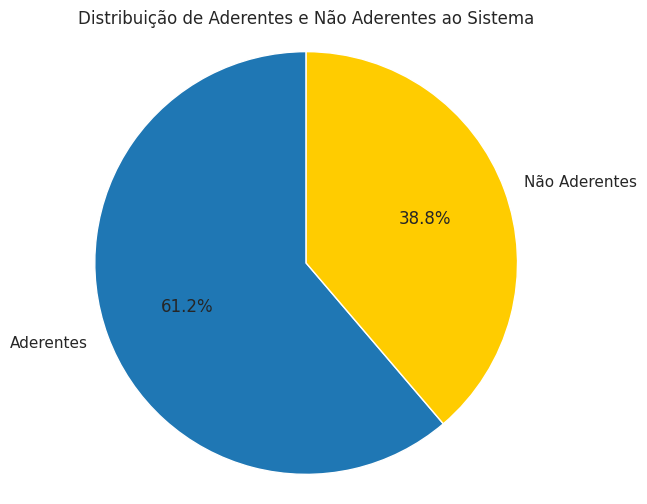

In [ ]:
#Gráfico de pizza
aderentes = 27520
nao_aderentes = 17417

labels = ['Aderentes', 'Não Aderentes']
values = [aderentes, nao_aderentes]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição de Aderentes e Não Aderentes ao Sistema')
plt.axis('equal')
plt.show()

##Plotagem de gráfico: Gráfico de correlação.

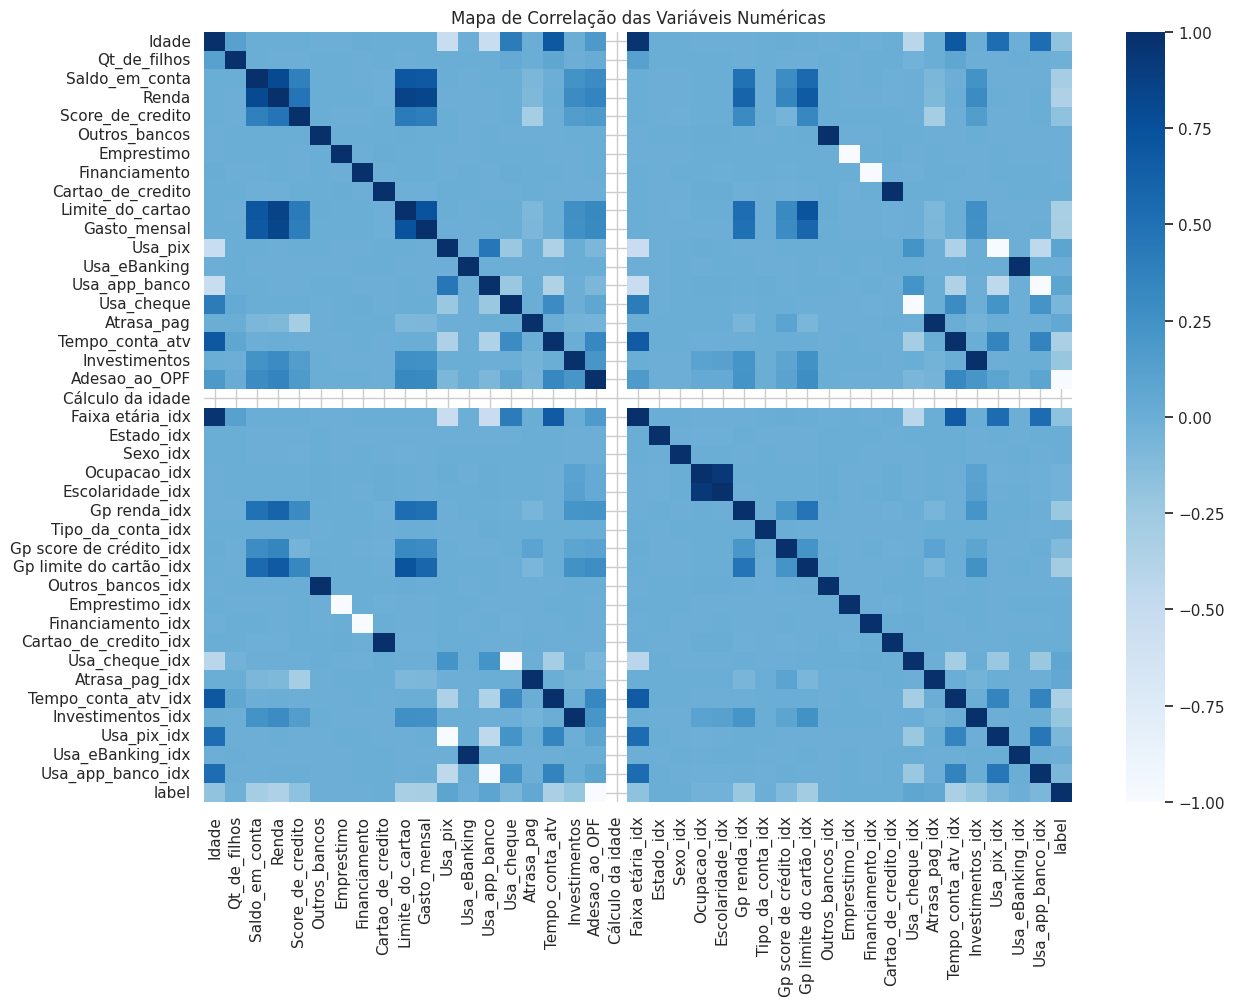

In [ ]:
#Gráfico de correlação entre as colunas indexadas
numeric_cols = [
    f.name for f in data_spark.schema.fields
    if isinstance(f.dataType, (IntegerType, DoubleType))
]

df_corr = data_spark.select(numeric_cols).toPandas()

plt.figure(figsize=(14,10))
sns.heatmap(df_corr.corr(), annot=False, cmap="Blues")
plt.title("Mapa de Correlação das Variáveis Numéricas")
plt.show()

## Plotagem de gráficos: Perfil demográfico do cliente.

/tmp/ipython-input-2485930138.py:4: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, x='Faixa etária', hue='Adesao_ao_OPF', palette= cores)


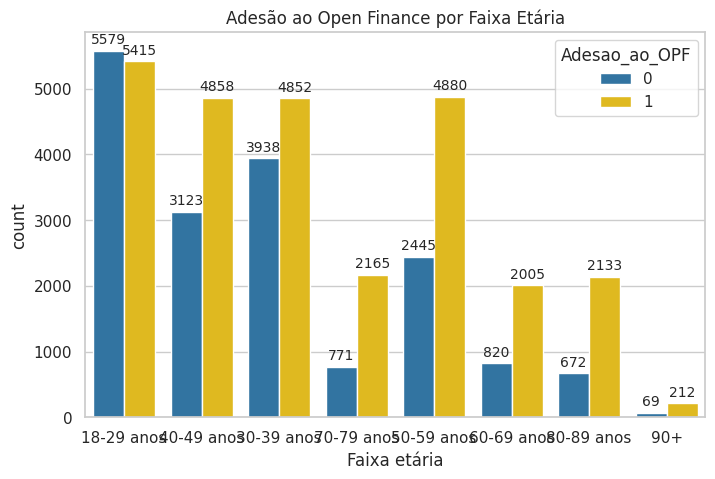

/tmp/ipython-input-2485930138.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, x='Sexo', hue='Adesao_ao_OPF', palette= cores)


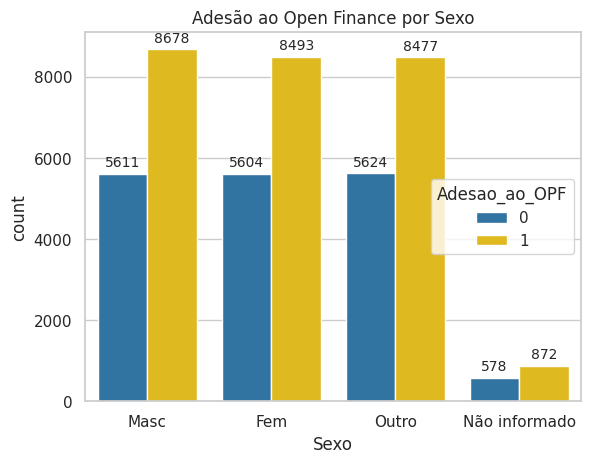

/tmp/ipython-input-2485930138.py:16: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, y='Escolaridade', hue='Adesao_ao_OPF', palette= cores)


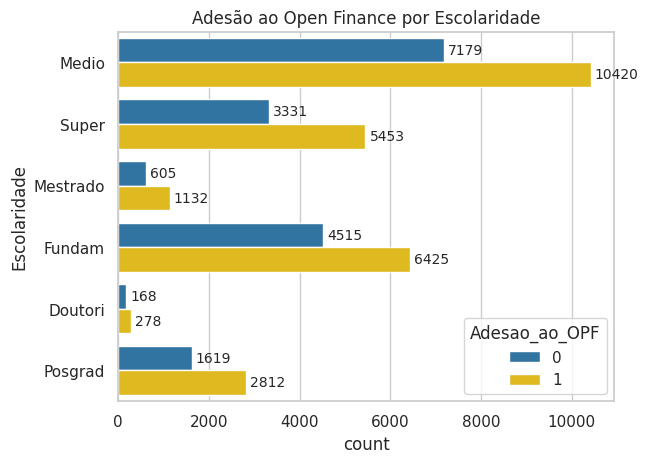

In [ ]:
data_pd = data_spark.select("Faixa etária", "Sexo", "Escolaridade", "Adesao_ao_OPF").toPandas()

plt.figure(figsize=(8,5))
dscp = sns.countplot(data=data_pd, x='Faixa etária', hue='Adesao_ao_OPF', palette= cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.title('Adesão ao Open Finance por Faixa Etária')
plt.show()

dscp = sns.countplot(data=data_pd, x='Sexo', hue='Adesao_ao_OPF', palette= cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.title('Adesão ao Open Finance por Sexo')
plt.show()

dscp = sns.countplot(data=data_pd, y='Escolaridade', hue='Adesao_ao_OPF', palette= cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.title('Adesão ao Open Finance por Escolaridade')
plt.show()

## Plotagem de gráficos: Perfil financeiro do cliente.

/tmp/ipython-input-3959115530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_pd, x='Adesao_ao_OPF', y='Gp renda', palette= cores)
/tmp/ipython-input-3959115530.py:3: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data_pd, x='Adesao_ao_OPF', y='Gp renda', palette= cores)


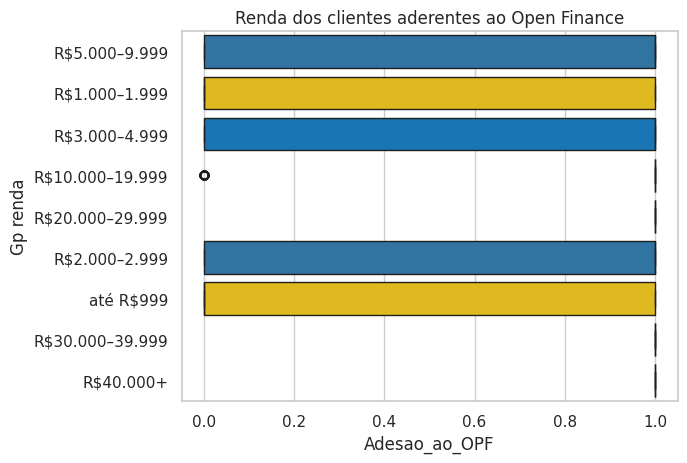

In [ ]:
data_pd = data_spark.select("Gp renda", "Adesao_ao_OPF").toPandas()

sns.boxplot(data=data_pd, x='Adesao_ao_OPF', y='Gp renda', palette= cores)
plt.title('Renda dos clientes aderentes ao Open Finance')
plt.show()

/tmp/ipython-input-2190981377.py:3: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, x='Gp renda', hue='Adesao_ao_OPF', palette=cores)


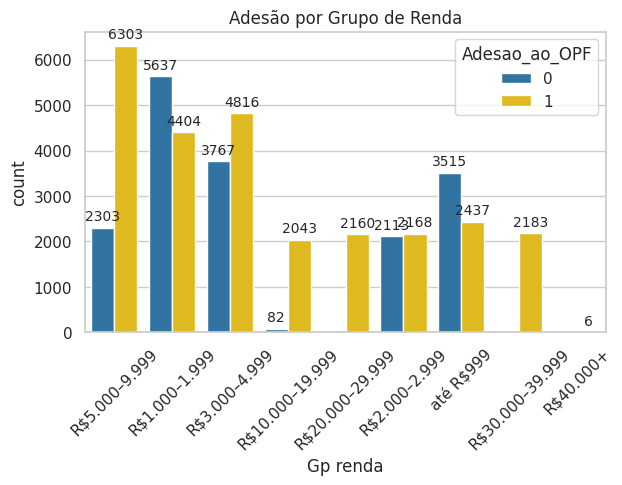

/tmp/ipython-input-2190981377.py:11: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, x='Gp score de crédito', hue='Adesao_ao_OPF', palette=cores)


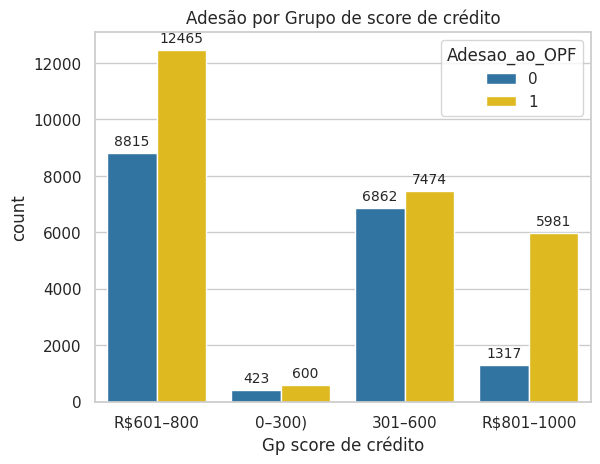

/tmp/ipython-input-2190981377.py:17: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  dscp = sns.countplot(data=data_pd, x='Gp gasto mensal', hue='Adesao_ao_OPF', palette=cores)


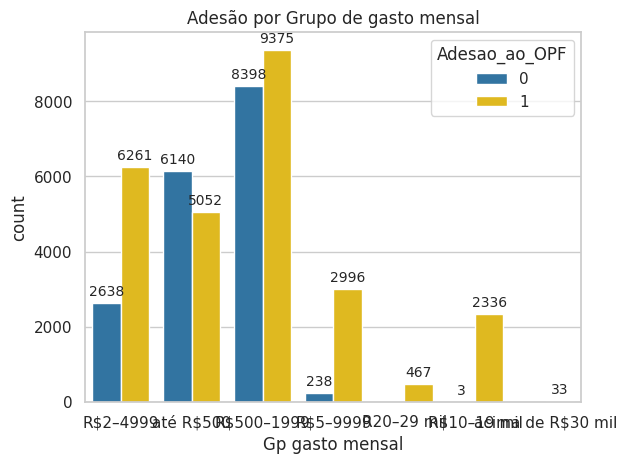

In [ ]:
data_pd = data_spark.select("Gp renda", "Gp score de crédito", "Gp gasto mensal", "Adesao_ao_OPF").toPandas()

dscp = sns.countplot(data=data_pd, x='Gp renda', hue='Adesao_ao_OPF', palette=cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Adesão por Grupo de Renda')
plt.show()

dscp = sns.countplot(data=data_pd, x='Gp score de crédito', hue='Adesao_ao_OPF', palette=cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.title('Adesão por Grupo de score de crédito')
plt.show()

dscp = sns.countplot(data=data_pd, x='Gp gasto mensal', hue='Adesao_ao_OPF', palette=cores)
for container in dscp.containers:
    dscp.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)
plt.title('Adesão por Grupo de gasto mensal')
plt.show()

##Plotagem de gráficos: Comportamento digital do cliente.

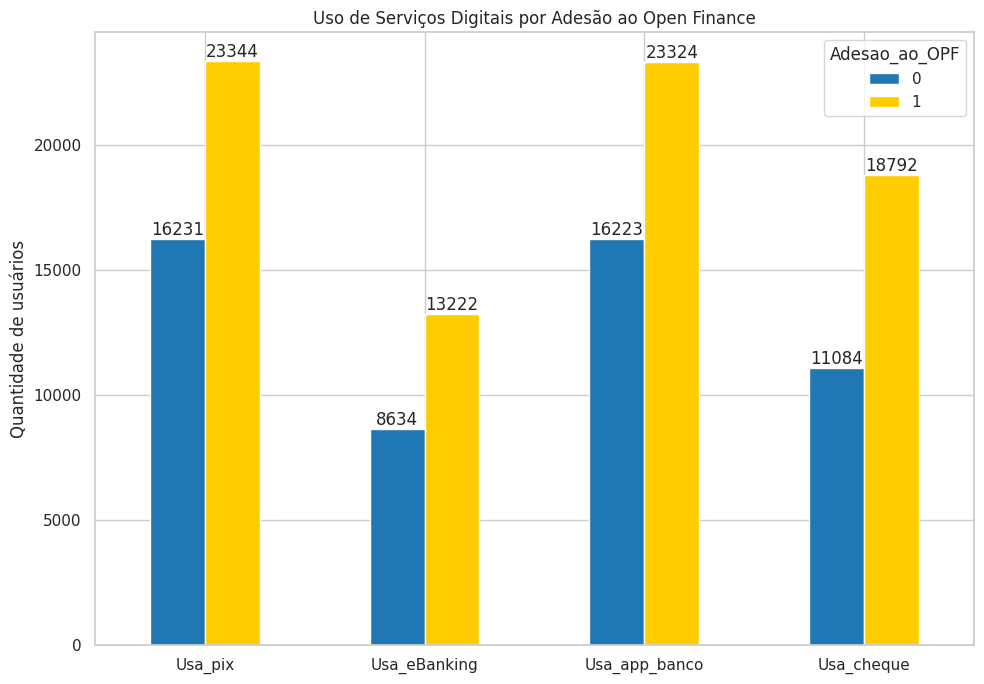

In [ ]:
df = data_spark.select(
    "Usa_pix", "Usa_eBanking", "Usa_app_banco", "Usa_cheque", "Adesao_ao_OPF").toPandas()

digital_cols = ['Usa_pix', 'Usa_eBanking', 'Usa_app_banco', 'Usa_cheque']

# Soma por categoria
adesao = df.groupby('Adesao_ao_OPF')[digital_cols].sum().T

dscp = adesao.plot(kind='bar', figsize=(10,7), color=["#1f77b4", "#ffcc00"])
plt.title('Uso de Serviços Digitais por Adesão ao Open Finance')
plt.ylabel('Quantidade de usuários')
plt.xticks(rotation=0)

for c in dscp.containers:
    dscp.bar_label(c, fmt='%d')

plt.tight_layout()
plt.show()


##Treinamento da aprendizagem de máquina

Para o treinamento da aprendizagem de máquina deste dataset foi considerado a métrica AUC como mais relevante para a valiação do desempenho do treinamento do modelo devido as particularidades da análise, como a importância de abranger todas as informações presentes sem exclusão de informações para uma predição precisa do perfil demográfico, comportamento digital e comprtamento financeiro dos clientes prováveis de aderir ao open finance.

In [ ]:
#Testando os melhores parâmetros para o treino
param_sets = [
    {"numTrees": 200, "maxDepth": 7, "maxBins": 150},
    {"numTrees": 300, "maxDepth": 10, "maxBins": 200}
]

evaluator = BinaryClassificationEvaluator(labelCol="label")
results = []


for params in param_sets:
    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=params["numTrees"],
        maxDepth=params["maxDepth"],
        maxBins=params["maxBins"],
        seed=42
    )

    model = rf.fit(train)
    pred = model.transform(test)
    auc = evaluator.evaluate(pred)

    #Mostrando o AUC
    results.append((params, auc))
    print(params, "AUC:", auc)

{'numTrees': 200, 'maxDepth': 7, 'maxBins': 150} AUC: 0.8203111681792374
{'numTrees': 300, 'maxDepth': 10, 'maxBins': 200} AUC: 0.8254395111350492


In [ ]:
#Considerando os hiper-parâmetros que geraram um melhor resultado
best_params, best_auc = max(results, key=lambda x: x[1])

print("Melhor AUC:", best_auc)
print("Melhores hiperparâmetros:", best_params)

Melhor AUC: 0.8254395111350492
Melhores hiperparâmetros: {'numTrees': 300, 'maxDepth': 10, 'maxBins': 200}


In [ ]:
#Re-treinar o modelo com os melhores hiperparâmetros
best_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=best_params["numTrees"],
    maxDepth=best_params["maxDepth"],
    maxBins=best_params["maxBins"],
    seed=42
)

final_model = best_rf.fit(train)
final_pred = final_model.transform(test)

print("Modelo final re-treinado com melhores hiperparâmetros!")

Modelo final re-treinado com melhores hiperparâmetros!


In [ ]:
#Criar novamente os avaliadores
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

#Recalcular métricas no modelo final
auc_final = evaluator_auc.evaluate(final_pred)
acc_final = evaluator_acc.evaluate(final_pred)
f1_final = evaluator_f1.evaluate(final_pred)

print("AUC:", auc_final)
print("Acurácia:", acc_final)
print("F1 Score:", f1_final)


AUC: 0.8254417325503725
Acurácia: 0.7422313954821694
F1 Score: 0.7431144207066609


##Avaliando o treino

In [ ]:
#Calculando métricas no modelo final
auc_final = evaluator_auc.evaluate(final_pred)
acc_final = evaluator_acc.evaluate(final_pred)
f1_final = evaluator_f1.evaluate(final_pred)

print("AUC:", auc_final)
print("Acurácia:", acc_final)
print("F1 Score:", f1_final)

AUC: 0.8254412389025195
Acurácia: 0.7422313954821694
F1 Score: 0.7431144207066609


In [ ]:
#Verificando a matriz de confusão
pred.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 2430|
|  0.0|       1.0| 1202|
|  1.0|       0.0| 1046|
|  0.0|       0.0| 4043|
+-----+----------+-----+



Matriz de Confusão (tabela):
prediction     0.0     1.0
label                     
0.0         4043.0  1202.0
1.0         1046.0  2430.0


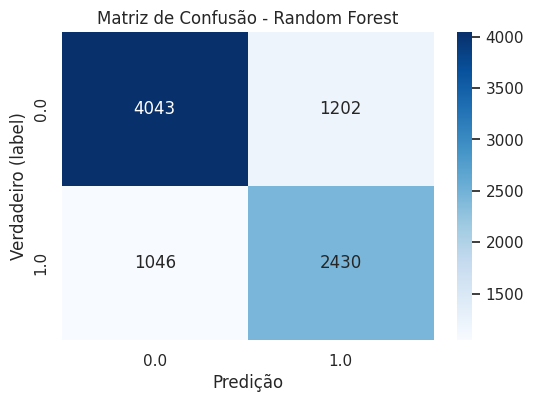

In [ ]:
#Transformando a predição em pandas para plotar o gráfico da matriz de confusão
confusion_df = pred.groupBy("label", "prediction").count().toPandas()

#Transformando em matriz 2x2
conf_matrix = pd.pivot_table(confusion_df, values='count', index='label', columns='prediction', fill_value=0)

#Ordenando para garantir posições corretas
conf_matrix = conf_matrix.sort_index().sort_index(axis=1)

print("Matriz de Confusão (tabela):")
print(conf_matrix)

#Plotando a matriz
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predição")
plt.ylabel("Verdadeiro (label)")
plt.show()

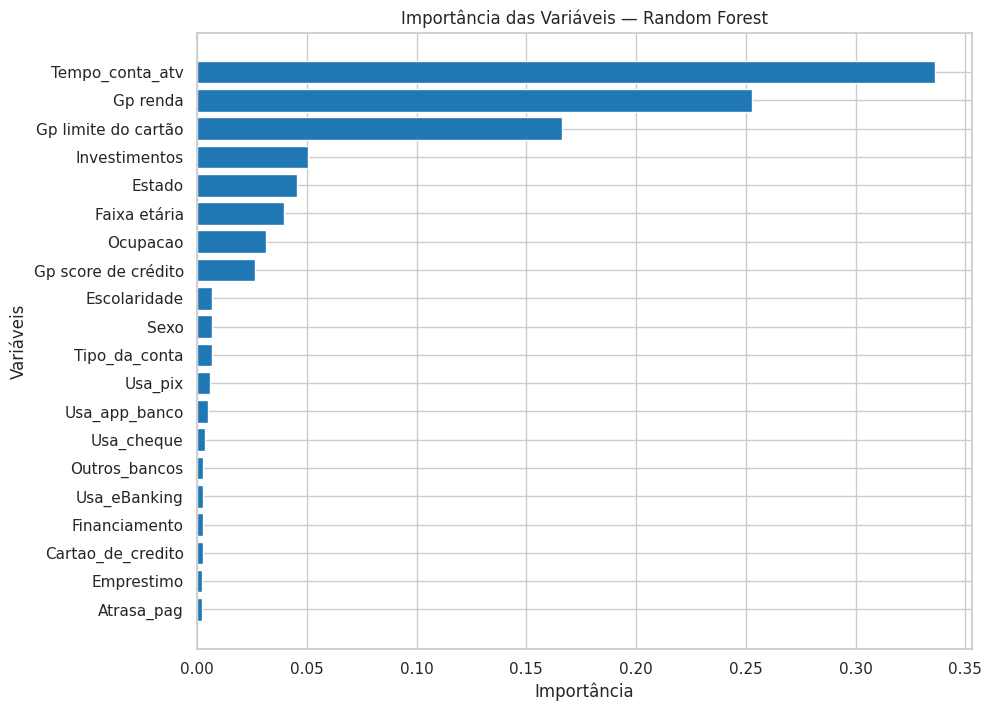

In [ ]:
#Importância das variáveis
feature_importances = model.featureImportances.toArray()

#Pegando os nomes das colunas usadas no VectorAssembler
cols = todas_features   # Use exatamente sua lista de features original

#Construir DataFrame de importâncias
df_imp = pd.DataFrame({"feature": cols, "importance": feature_importances}).sort_values("importance", ascending=False)

#Plotando os gráficos
plt.figure(figsize=(10,8))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.title("Importância das Variáveis — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.gca().invert_yaxis() #Para a mais importante ficar no topo
plt.show()

##Salvando o modelo

In [ ]:
save_path = "/content/modelo_openfinance_rf"

#Caso já exista, sobrescreve
final_model.write().overwrite().save(save_path)

print("Modelo salvo em:", save_path)

Modelo salvo em: /content/modelo_openfinance_rf


In [ ]:
!zip -r modelo_openfinance_rf.zip /content/modelo_openfinance_rf
from google.colab import files
files.download("modelo_openfinance_rf.zip")

  adding: content/modelo_openfinance_rf/ (stored 0%)
  adding: content/modelo_openfinance_rf/data/ (stored 0%)
  adding: content/modelo_openfinance_rf/data/part-00000-489385c0-ed23-448e-aad7-888aad4bb711-c000.snappy.parquet (deflated 18%)
  adding: content/modelo_openfinance_rf/data/_SUCCESS (stored 0%)
  adding: content/modelo_openfinance_rf/data/._SUCCESS.crc (stored 0%)
  adding: content/modelo_openfinance_rf/data/.part-00000-489385c0-ed23-448e-aad7-888aad4bb711-c000.snappy.parquet.crc (deflated 0%)
  adding: content/modelo_openfinance_rf/treesMetadata/ (stored 0%)
  adding: content/modelo_openfinance_rf/treesMetadata/_SUCCESS (stored 0%)
  adding: content/modelo_openfinance_rf/treesMetadata/._SUCCESS.crc (stored 0%)
  adding: content/modelo_openfinance_rf/treesMetadata/part-00000-48aadd36-860a-4741-91fd-88ba2c46ba35-c000.snappy.parquet (deflated 22%)
  adding: content/modelo_openfinance_rf/treesMetadata/.part-00000-48aadd36-860a-4741-91fd-88ba2c46ba35-c000.snappy.parquet.crc (store

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>